In [41]:
import os
import json
import pandas as pd
import matplotlib.pyplot as plt

DATA_DIR = "../data/defects4j"

R = "Relevent"
P = "Partially Relevant"
I = "Irrelevant"

with open("../results/relevance_eval/aggregated_rpi.json", "r") as f:
    aggregated_rpi = json.load(f)

for bug_name, items in aggregated_rpi.items():
    items['sim'] = items['sim_scores']
    items['rpi_list'] = [eval(r) for r in items['rpi_list']]
rpi_data = aggregated_rpi


def calc_acc_at_n(data, bug_name, n_rank=1):
    """
    Calculate Acc@N (Accuracy at N)
    Returns success bug count / total bug count
    """
    buggy_methods = data.get("buggy_methods", {})
    target_bug_data = buggy_methods.get(bug_name)
    if not target_bug_data:
        return 0
    
    ranks = [
        info.get("autofl_rank")
        for info in target_bug_data.values()
        if isinstance(info, dict) and info.get("autofl_rank") is not None
    ]
    
    return min(ranks)


In [42]:
N_RANK = 10
REPETITION = 1
TIMEWINDOW=30

# GPT_VERSION = "gpt-3.5-turbo-0125"
GPT_VERSION = "gpt-4.1-mini-2025-04-14"

/tmp/ipykernel_4030350/1891183919.py:17: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot(


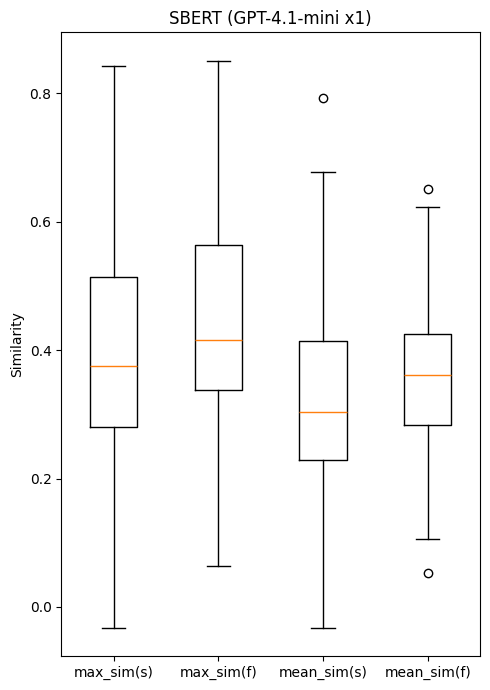

/tmp/ipykernel_4030350/1891183919.py:17: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot(


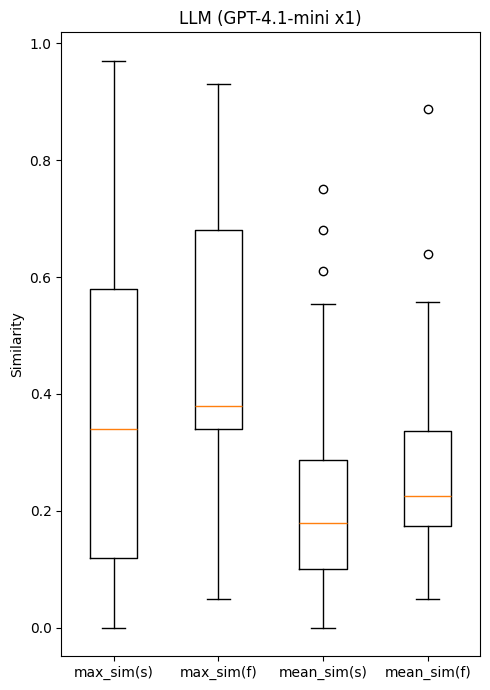

In [43]:
RESULT_CR_PATH = f"../combined_fl_results/current/{GPT_VERSION}_R{REPETITION}_full_light.json"
RESULT_RECENT_PATH_EXP_NAME = (
    "reportfl"
    if TIMEWINDOW == 30
    else f"reportfl_{TIMEWINDOW}days"
)
RESULT_RECENT_PATH = f"../combined_fl_results/{RESULT_RECENT_PATH_EXP_NAME}/{GPT_VERSION}_R{REPETITION}_full_light.json"

def draw_boxplot(results, title):
    df = pd.DataFrame(results)

    df_success = df[df['acc'] <= N_RANK]
    df_failed = df[df['acc'] > N_RANK]

    fig, ax = plt.subplots(figsize=(5, 7))

    ax.boxplot(
        [
            df_success['max_sim'].dropna(),
            df_failed['max_sim'].dropna(),
            df_success['mean_sim'].dropna(),
            df_failed['mean_sim'].dropna(),
        ],
        labels=[
            'max_sim(s)',
            'max_sim(f)',
            'mean_sim(s)',
            'mean_sim(f)'
        ]
    )

    ax.set_title(title)
    ax.set_ylabel('Similarity')

    plt.tight_layout()
    plt.show()

with open(RESULT_RECENT_PATH, "r", encoding="utf-8") as f:
    fl_result = json.load(f)

sbert_sims_results = []
llm_sims_results = []

for bug_name in sorted(os.listdir(DATA_DIR)):
    current_file_path = os.path.join(DATA_DIR, bug_name, "current_report.json")
    recent_reports_file_path = os.path.join(DATA_DIR, bug_name, f"relevant_reports_timewindow_{TIMEWINDOW}.json")
    
    if not os.path.isfile(current_file_path):
        continue

    if os.path.isfile(recent_reports_file_path):
        acc = calc_acc_at_n(fl_result, bug_name, N_RANK)
        # SBERT sims
        with open(recent_reports_file_path, "r", encoding="utf-8") as f:
            relevant_reports = json.load(f)
            sims = [report["similarity"] for report in relevant_reports[:3]]
            max_sim = max(sims)
            mean_sim = sum(sims) / len(sims)

        sbert_sims_results.append({
            'bug_name': bug_name, 'acc': acc, 'max_sim': max_sim, 'mean_sim': mean_sim
        })

        # LLM sims
        sims = rpi_data[bug_name]['llm_simscores']
        max_sim = max(sims)
        mean_sim = sum(sims) / len(sims)

        llm_sims_results.append({
            'bug_name': bug_name, 'acc': acc, 'max_sim': max_sim, 'mean_sim': mean_sim
        })

draw_boxplot(
    sbert_sims_results,
    f'SBERT (GPT-{GPT_VERSION.split("-")[1]}-{GPT_VERSION.split("-")[2]} x{REPETITION})'
)

draw_boxplot(
    llm_sims_results,
    f'LLM (GPT-{GPT_VERSION.split("-")[1]}-{GPT_VERSION.split("-")[2]} x{REPETITION})'
)

SBERT (GPT-4.1-mini x1)
Acc@10 Success : 155
Acc@10 Failed  : 50
Acc@10 Rate    : 0.756


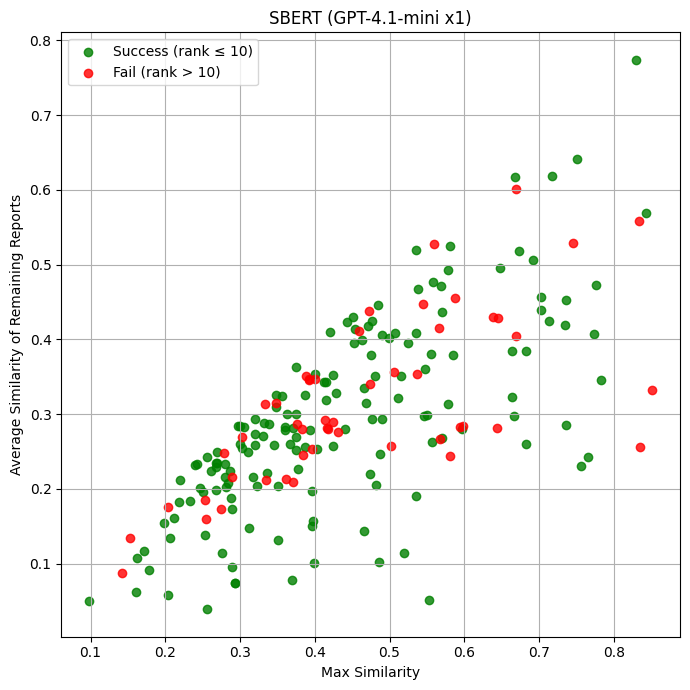

LLM (GPT-4.1-mini x1)
Acc@10 Success : 187
Acc@10 Failed  : 59
Acc@10 Rate    : 0.760


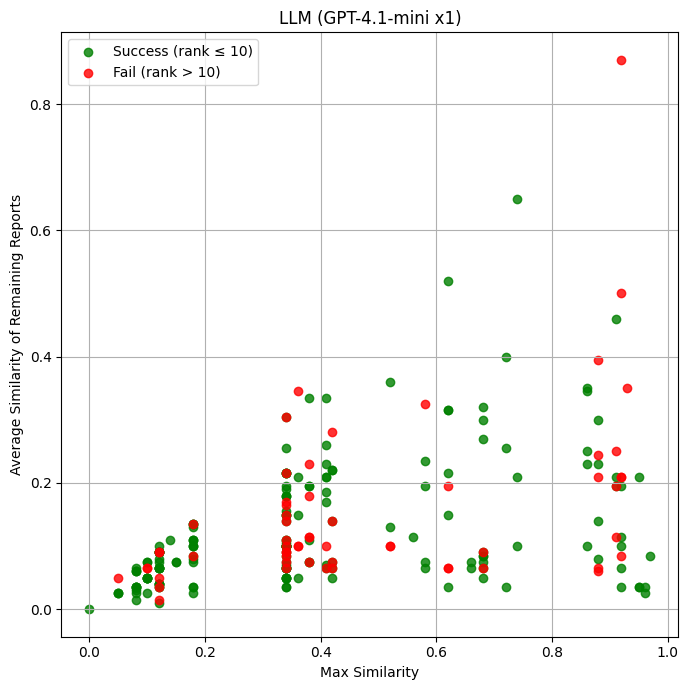

In [44]:
def draw_scatter(results, title):
    df = pd.DataFrame(results)

    df_success = df[df['acc'] <= N_RANK]
    df_failed = df[df['acc'] > N_RANK]

    print(f"{title}")
    print(f"Acc@{N_RANK} Success : {len(df_success)}")
    print(f"Acc@{N_RANK} Failed  : {len(df_failed)}")
    print(f"Acc@{N_RANK} Rate    : {len(df_success) / len(df):.3f}")

    fig, ax = plt.subplots(figsize=(7, 7))

    ax.scatter(
        df_success["max_sim"],
        df_success["other_avg"],
        c="green",
        alpha=0.8,
        label=f"Success (rank ≤ {N_RANK})"
    )

    ax.scatter(
        df_failed["max_sim"],
        df_failed["other_avg"],
        c="red",
        alpha=0.8,
        label=f"Fail (rank > {N_RANK})"
    )

    ax.set_xlabel("Max Similarity")
    ax.set_ylabel("Average Similarity of Remaining Reports")
    ax.set_title(title)

    ax.grid(True)
    ax.legend()

    plt.tight_layout()
    plt.show()
    
sbert_sims_results = []
llm_sims_results = []

for bug_name in sorted(os.listdir(DATA_DIR)):
    current_file_path = os.path.join(
        DATA_DIR,
        bug_name,
        "current_report.json"
    )

    recent_reports_file_path = os.path.join(
        DATA_DIR,
        bug_name,
        f"relevant_reports_timewindow_{TIMEWINDOW}.json"
    )

    if not os.path.isfile(current_file_path):
        continue

    if not os.path.isfile(recent_reports_file_path):
        continue

    acc = calc_acc_at_n(
        fl_result,
        bug_name,
        N_RANK
    )

    # SBERT
    with open(recent_reports_file_path, "r", encoding="utf-8") as f:
        relevant_reports = json.load(f)

    sims = sorted(
        [report["similarity"] for report in relevant_reports[:3]],
        reverse=True
    )

    if len(sims) >= 3:
        sbert_sims_results.append({
            "bug_name": bug_name,
            "acc": acc,
            "max_sim": sims[0],
            "other_avg": (sims[1] + sims[2]) / 2
        })

    # LLM
    sims = sorted(
        rpi_data[bug_name]["llm_simscores"],
        reverse=True
    )

    if len(sims) >= 3:
        llm_sims_results.append({
            "bug_name": bug_name,
            "acc": acc,
            "max_sim": sims[0],
            "other_avg": (sims[1] + sims[2]) / 2
        })

draw_scatter(
    sbert_sims_results,
    f'SBERT (GPT-{GPT_VERSION.split("-")[1]}-{GPT_VERSION.split("-")[2]} x{REPETITION})'
)

draw_scatter(
    llm_sims_results,
    f'LLM (GPT-{GPT_VERSION.split("-")[1]}-{GPT_VERSION.split("-")[2]} x{REPETITION})'
)

SBERT - CR Success (rank <= 10)
CR better       : 16
ReportFL better : 9
Tie             : 126


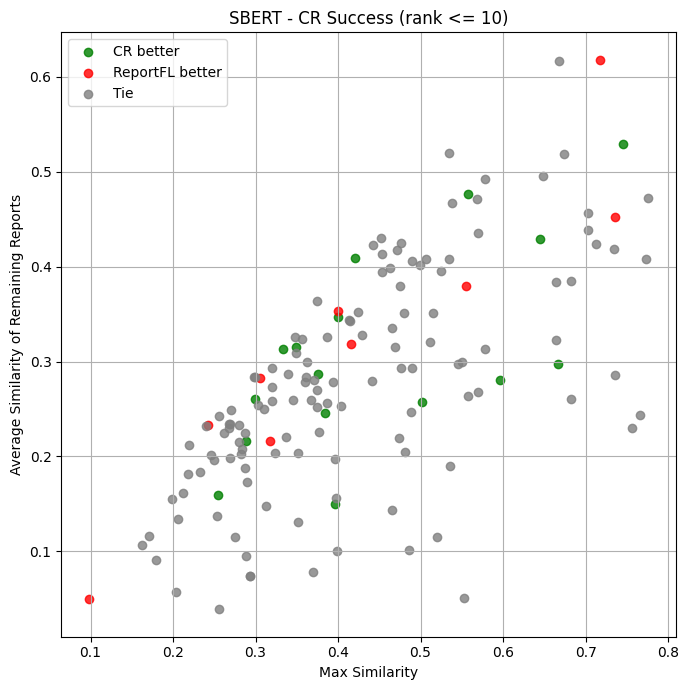

LLM - CR Success (rank <= 10)
CR better       : 17
ReportFL better : 10
Tie             : 156


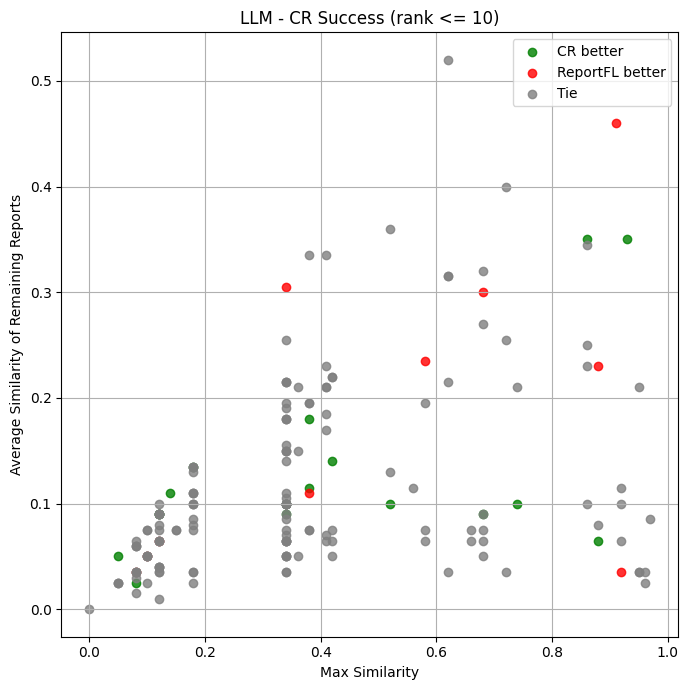

In [45]:
def draw_rank_compare_scatter(results, title):
    df = pd.DataFrame(results)

    df_cr_win = df[df["rank_diff"] < 0]
    df_reportfl_win = df[df["rank_diff"] > 0]
    df_tie = df[df["rank_diff"] == 0]

    print(f"{title}")
    print(f"CR better       : {len(df_cr_win)}")
    print(f"ReportFL better : {len(df_reportfl_win)}")
    print(f"Tie             : {len(df_tie)}")

    fig, ax = plt.subplots(figsize=(7, 7))

    ax.scatter(
        df_cr_win["max_sim"],
        df_cr_win["other_avg"],
        c="green",
        alpha=0.8,
        label="CR better"
    )

    ax.scatter(
        df_reportfl_win["max_sim"],
        df_reportfl_win["other_avg"],
        c="red",
        alpha=0.8,
        label="ReportFL better"
    )

    ax.scatter(
        df_tie["max_sim"],
        df_tie["other_avg"],
        c="gray",
        alpha=0.8,
        label="Tie"
    )

    ax.set_xlabel("Max Similarity")
    ax.set_ylabel("Average Similarity of Remaining Reports")
    ax.set_title(title)

    ax.grid(True)
    ax.legend()

    plt.tight_layout()
    plt.show()

sbert_cr_success = []
sbert_reportfl_success = []

llm_cr_success = []
llm_reportfl_success = []

with open(RESULT_CR_PATH, "r", encoding="utf-8") as f:
    current_fl_result = json.load(f)

with open(RESULT_RECENT_PATH, "r", encoding="utf-8") as f:
    recent_fl_result = json.load(f)

for bug_name in sorted(os.listdir(DATA_DIR)):
    current_file_path = os.path.join(
        DATA_DIR,
        bug_name,
        "current_report.json"
    )

    recent_reports_file_path = os.path.join(
        DATA_DIR,
        bug_name,
        f"relevant_reports_timewindow_{TIMEWINDOW}.json"
    )

    if not os.path.isfile(current_file_path):
        continue

    if not os.path.isfile(recent_reports_file_path):
        continue
    
    cr_rank = calc_acc_at_n(current_fl_result, bug_name, N_RANK)
    reportfl_rank = calc_acc_at_n(recent_fl_result, bug_name, N_RANK)

    if cr_rank is None or reportfl_rank is None:
        continue

    rank_diff = cr_rank - reportfl_rank

    # SBERT
    with open(recent_reports_file_path, "r", encoding="utf-8") as f:
        relevant_reports = json.load(f)

    sims = sorted(
        [report["similarity"] for report in relevant_reports[:3]],
        reverse=True
    )

    if len(sims) >= 3:
        row = {
            "bug_name": bug_name,
            "max_sim": sims[0],
            "other_avg": (sims[1] + sims[2]) / 2,
            "rank_diff": rank_diff,
        }

        if cr_rank <= N_RANK:
            sbert_cr_success.append(row)

        if reportfl_rank <= N_RANK:
            sbert_reportfl_success.append(row)

    # LLM
    sims = sorted(
        rpi_data[bug_name]["llm_simscores"],
        reverse=True
    )

    if len(sims) >= 3:
        row = {
            "bug_name": bug_name,
            "max_sim": sims[0],
            "other_avg": (sims[1] + sims[2]) / 2,
            "rank_diff": rank_diff,
        }

        if cr_rank <= N_RANK:
            llm_cr_success.append(row)

        if reportfl_rank <= N_RANK:
            llm_reportfl_success.append(row)

draw_rank_compare_scatter(
    sbert_cr_success,
    f"SBERT - CR Success (rank <= {N_RANK})"
)

# draw_rank_compare_scatter(
#     sbert_reportfl_success,
#     f"SBERT - ReportFL Success (rank <= {N_RANK})"
# )

draw_rank_compare_scatter(
    llm_cr_success,
    f"LLM - CR Success (rank <= {N_RANK})"
)

# draw_rank_compare_scatter(
#     llm_reportfl_success,
#     f"LLM - ReportFL Success (rank <= {N_RANK})"
# )